In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
from utils.yolo import detect_objects
import os
from ultralytics import YOLO
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

(np.float64(-0.5), np.float64(1150.5), np.float64(862.5), np.float64(-0.5))

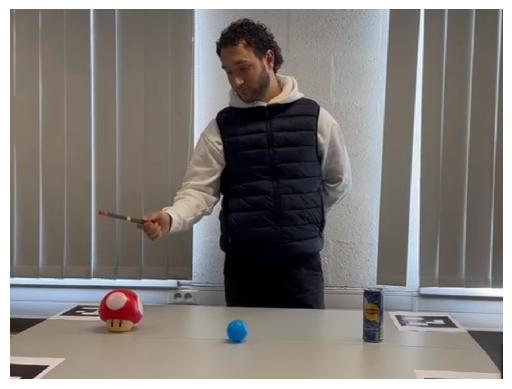

In [2]:
img = cv2.imread("../input/05.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 

In [3]:
masks,labels =detect_objects(img)
bottle_mask = masks[3]
bottle_mask
# plt.imshow(bottle_mask, cmap='gray')
# plt.axis('off') 

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(863, 1151), dtype=uint8)

In [22]:
def generate_rainbow_colors(n):
    """Generate n distinct RGB colors evenly spaced on the HSV wheel."""
    colors = []
    for i in range(n):
        h = i / n
        r, g, b = colorsys.hsv_to_rgb(h, 1.0, 1.0)
        colors.append([int(r * 255), int(g * 255), int(b * 255)])
    return np.array(colors, dtype=np.uint8)

def create_kalman_filter():
    kf = cv2.KalmanFilter(8, 4)  # 8 states, 4 measurements

    dt = 1  # one frame

    kf.transitionMatrix = np.array([
        [1,0,0,0, dt,0,0,0],
        [0,1,0,0, 0,dt,0,0],
        [0,0,1,0, 0,0,dt,0],
        [0,0,0,1, 0,0,0,dt],
        [0,0,0,0, 1,0,0,0 ],
        [0,0,0,0, 0,1,0,0 ],
        [0,0,0,0, 0,0,1,0 ],
        [0,0,0,0, 0,0,0,1 ],
    ], np.float32)

    kf.measurementMatrix = np.eye(4, 8, dtype=np.float32)
    kf.processNoiseCov = np.eye(8, dtype=np.float32) * 0.001
    kf.measurementNoiseCov = np.eye(4, dtype=np.float32) * 0.05

    return kf


In [25]:
class KFBoxTracker:
    def __init__(self, x1, y1, x2, y2):
        self.kf = cv2.KalmanFilter(8, 4)

        dt = 1
        self.kf.transitionMatrix = np.array([
            [1,0,0,0, dt,0,0,0],
            [0,1,0,0, 0,dt,0,0],
            [0,0,1,0, 0,0,dt,0],
            [0,0,0,1, 0,0,0,dt],
            [0,0,0,0, 1,0,0,0 ],
            [0,0,0,0, 0,1,0,0 ],
            [0,0,0,0, 0,0,1,0 ],
            [0,0,0,0, 0,0,0,1 ],
        ], np.float32)

        self.kf.measurementMatrix = np.eye(4, 8, dtype=np.float32)
        self.kf.processNoiseCov = np.eye(8, dtype=np.float32) * 0.001
        self.kf.measurementNoiseCov = np.eye(4, dtype=np.float32) * 0.05

        # initialize
        self.kf.statePre = np.array([[x1],[y1],[x2],[y2],[0],[0],[0],[0]], np.float32)
        self.bbox = (x1, y1, x2, y2)

    def predict(self):
        pred = self.kf.predict()
        x1,y1,x2,y2 = map(int, pred[:4])
        self.bbox = (x1,y1,x2,y2)
        return self.bbox

    def correct(self, x1, y1, x2, y2):
        meas = np.array([[x1],[y1],[x2],[y2]], np.float32)
        self.kf.correct(meas)
        self.bbox = (x1,y1,x2,y2)
        return self.bbox


In [26]:
def annotate_video(in_path, read_every_x_frame=2, out_path=None, confidence_threshold=0.0):

    cap = cv2.VideoCapture(in_path)
    if not out_path:
        file_name = os.path.basename(in_path)[:-4]
        out_path = f"{file_name}.mp4"

    fps = cap.get(cv2.CAP_PROP_FPS)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    class_names = model.model.names
    colors = generate_rainbow_colors(len(class_names))

    # MULTI TRACKERS (one per label)
    trackers = {}   # label → KFBoxTracker
    last_conf = {}  # for logging

    for frame_idx in range(total_frames):

        ok, frame = cap.read()
        if not ok:
            break

        annotated = frame.copy()

        # ----------------------------------------------------------
        # YOLO FRAME
        # ----------------------------------------------------------
        if frame_idx % read_every_x_frame == 0:

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = model(rgb, verbose=False)[0]
            boxes = results.boxes

            detected_labels = set()

            for box in boxes:
                conf = float(box.conf[0])
                if conf < confidence_threshold:
                    continue

                cls_id = int(box.cls[0])
                label = class_names[cls_id]
                color = colors[cls_id].tolist()

                x1,y1,x2,y2 = map(int, box.xyxy[0])
                detected_labels.add(label)

                # --- create tracker if first time ---
                if label not in trackers:
                    trackers[label] = KFBoxTracker(x1,y1,x2,y2)

                # --- correct KF with YOLO detection ---
                trackers[label].correct(x1,y1,x2,y2)
                last_conf[label] = conf

            # --- objects NOT detected this YOLO frame: predict ---
            for label, tracker in trackers.items():
                if label not in detected_labels:
                    tracker.predict()

        # ----------------------------------------------------------
        # NON-YOLO FRAME → ONLY PREDICT
        # ----------------------------------------------------------
        else:
            for label, tracker in trackers.items():
                tracker.predict()

        # ----------------------------------------------------------
        # DRAW ALL TRACKERS
        # ----------------------------------------------------------
        for label, tracker in trackers.items():
            x1,y1,x2,y2 = tracker.bbox
            class_id = list(class_names.values()).index(label)
            color = colors[class_id].tolist()

            cv2.rectangle(annotated, (x1,y1), (x2,y2), color, 2)
            txt = f"{label} (pred)" if frame_idx % read_every_x_frame else f"{label} {last_conf.get(label,0):.2f}"
            cv2.putText(annotated, txt, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        writer.write(annotated)

    cap.release()
    writer.release()


In [28]:
in_path = f"../input/dynamic/trick2.mp4"
out_path= f"../output/trick2_annotated.mp4"
model = YOLO('yolov8n.pt')  # Load the model ONCE
annotate_video(in_path, read_every_x_frame=10, out_path = out_path, confidence_threshold=0.0)

C:\Users\user\AppData\Local\Temp\ipykernel_20236\4118134436.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x1,y1,x2,y2 = map(int, pred[:4])


In [31]:
class KFBoxTracker:
    def __init__(self):
        self.kf = cv2.KalmanFilter(8, 4)

        dt = 1.0

        self.kf.transitionMatrix = np.array([
            [1,0,0,0, dt,0,0,0],
            [0,1,0,0, 0,dt,0,0],
            [0,0,1,0, 0,0,dt,0],
            [0,0,0,1, 0,0,0,dt],
            [0,0,0,0, 1,0,0,0 ],
            [0,0,0,0, 0,1,0,0 ],
            [0,0,0,0, 0,0,1,0 ],
            [0,0,0,0, 0,0,0,1 ],
        ], np.float32)

        self.kf.measurementMatrix = np.eye(4, 8, dtype=np.float32)
        self.kf.processNoiseCov   = np.eye(8, dtype=np.float32) * 0.001
        self.kf.measurementNoiseCov = np.eye(4, dtype=np.float32) * 0.05

        self.initialized = False

    def init(self, x1, y1, x2, y2):
        self.kf.statePost = np.array([
            [x1],[y1],[x2],[y2],[0],[0],[0],[0]
        ], np.float32)
        self.initialized = True

    def predict(self):
        pred = self.kf.predict()
        x1, y1, x2, y2 = map(float, pred[:4])
        return (x1, y1, x2, y2)

    def correct(self, x1, y1, x2, y2):
        meas = np.array([[x1],[y1],[x2],[y2]], np.float32)
        corrected = self.kf.correct(meas)
        return tuple(float(corrected[i]) for i in range(4))


In [38]:
def forward_pass_collect(in_path, model, read_every=10, conf_thr=0.3):

    cap = cv2.VideoCapture(in_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    tracker = KFBoxTracker()

    forward_states = []      # KF statePost for each frame
    forward_covs   = []      # KF covariance for each frame
    predictions    = []      # predicted bbox per frame
    measurements   = [None]*total  # YOLO detections per frame

    for i in range(total):
        ok, frame = cap.read()
        if not ok: break

        if i % read_every == 0:
            # YOLO detection
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = model(rgb, verbose=False)[0]
            boxes = results.boxes

            best = None
            best_conf = 0
            for box in boxes:
                conf = float(box.conf[0])
                if conf < conf_thr: continue
                if conf > best_conf:
                    best_conf = conf
                    best = box

            if best is not None:
                x1,y1,x2,y2 = map(float, best.xyxy[0])
                if not tracker.initialized:
                    tracker.init(x1,y1,x2,y2)
                tracker.correct(x1,y1,x2,y2)
                measurements[i] = (x1,y1,x2,y2)
            else:
                # no detection
                tracker.predict()
        else:
            tracker.predict()

        # store KF state + covariance for smoothing
        forward_states.append(tracker.kf.statePost.copy())
        forward_covs.append(tracker.kf.errorCovPost.copy())

        # store predicted bbox
        px1,py1,px2,py2 = tracker.kf.statePost[:4]
        predictions.append((float(px1),float(py1),float(px2),float(py2)))

    cap.release()
    return predictions, measurements, forward_states, forward_covs
def rts_smoother(forward_states, forward_covs, tracker):

    F = tracker.kf.transitionMatrix
    T = len(forward_states)

    smoothed_states = [None]*T

    smoothed_states[-1] = forward_states[-1].copy()
    P_smooth = forward_covs[-1].copy()

    for t in range(T-2, -1, -1):

        P_t     = forward_covs[t]
        x_t     = forward_states[t]
        x_pred  = F @ x_t
        P_pred  = F @ P_t @ F.T + tracker.kf.processNoiseCov

        # smoother gain
        C = P_t @ F.T @ np.linalg.inv(P_pred)

        # smoothed state
        smoothed_states[t] = x_t + C @ (smoothed_states[t+1] - x_pred)

        # smoothed covariance (not really needed for bbox)
        P_smooth = P_t + C @ (P_smooth - P_pred) @ C.T

    return smoothed_states
def render_smoothed_video(in_path, out_path, smoothed_states):

    cap = cv2.VideoCapture(in_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = cv2.VideoWriter(out_path,
                             cv2.VideoWriter_fourcc(*"mp4v"),
                             fps, (w,h))

    i = 0
    while True:
        ok, frame = cap.read()
        if not ok: break

        sx1,sy1,sx2,sy2 = map(int, smoothed_states[i][:4])

        cv2.rectangle(frame, (sx1,sy1), (sx2,sy2), (0,0,255), 2)
        cv2.putText(frame, "RTS Smoothed", (sx1, sy1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)

        writer.write(frame)
        i += 1

    cap.release()
    writer.release()
def IoU(boxA, boxB):
    ax1,ay1,ax2,ay2 = boxA
    bx1,by1,bx2,by2 = boxB

    interX1 = max(ax1, bx1)
    interY1 = max(ay1, by1)
    interX2 = min(ax2, bx2)
    interY2 = min(ay2, by2)

    interArea = max(0, interX2 - interX1) * max(0, interY2 - interY1)
    areaA = (ax2-ax1)*(ay2-ay1)
    areaB = (bx2-bx1)*(by2-by1)

    return interArea / max(areaA + areaB - interArea, 1e-6)
def forward_pass_multi(in_path, model, read_every=10, conf_thr=0.3):

    cap = cv2.VideoCapture(in_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    next_id = 0
    trackers = {}  # id -> KFBoxTracker

    # Storage for smoothing
    forward_states = {}    # id -> list of states
    forward_covs   = {}    # id -> list of covariances
    measurements   = {}    # id -> list of measurements OR None

    for i in range(total):
        ok, frame = cap.read()
        if not ok:
            break

        detections = []
        if i % read_every == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            yol = model(rgb, verbose=False)[0]
            for box in yol.boxes:
                conf = float(box.conf[0])
                if conf < conf_thr: continue
                x1,y1,x2,y2 = map(float, box.xyxy[0])
                detections.append((x1,y1,x2,y2))

        # --- prediction step for all trackers ---
        predicted_boxes = {}
        for tid, trk in trackers.items():
            predicted_boxes[tid] = trk.predict()

        # --- match YOLO detections to trackers ---
        unmatched_dets = detections.copy()
        matched = set()

        for tid, pred in predicted_boxes.items():
            best_iou = 0
            best_det = None
            for det in unmatched_dets:
                iou = IoU(pred, det)
                if iou > best_iou:
                    best_iou = iou
                    best_det = det

            if best_iou > 0.3:  # threshold
                x1,y1,x2,y2 = best_det
                trackers[tid].correct(x1,y1,x2,y2)
                matched.add(tid)
                unmatched_dets.remove(best_det)
            # else: prediction only (already done)

        # --- new trackers for remaining detections ---
        for det in unmatched_dets:
            x1,y1,x2,y2 = det
            tracker = KFBoxTracker()
            tracker.init(x1,y1,x2,y2)
            trackers[next_id] = tracker
            next_id += 1

        # --- save forward states ---
        for tid, trk in trackers.items():
            if tid not in forward_states:
                forward_states[tid] = []
                forward_covs[tid]   = []
                measurements[tid]   = [None]*total

            forward_states[tid].append(trk.kf.statePost.copy())
            forward_covs[tid].append(trk.kf.errorCovPost.copy())

            # store measurement if used
            if tid in matched:
                measurements[tid][i] = tuple(trk.kf.statePost[:4].flatten())

    cap.release()
    return trackers.keys(), forward_states, forward_covs, measurements
def rts_smoother_per_track(states, covs, tracker_template):

    F = tracker_template.kf.transitionMatrix
    Q = tracker_template.kf.processNoiseCov

    T = len(states)
    smoothed = [None]*T

    smoothed[-1] = states[-1].copy()
    P_smooth = covs[-1].copy()

    for t in range(T-2, -1, -1):
        x_t = states[t]
        P_t = covs[t]

        x_pred = F @ x_t
        P_pred = F @ P_t @ F.T + Q

        C = P_t @ F.T @ np.linalg.inv(P_pred)

        smoothed[t] = x_t + C @ (smoothed[t+1] - x_pred)
        P_smooth = P_t + C @ (P_smooth - P_pred) @ C.T

    return smoothed
def smooth_all_tracks(track_ids, forward_states, forward_covs):
    smoothed_tracks = {}

    for tid in track_ids:
        trk_template = KFBoxTracker()
        smoothed = rts_smoother_per_track(forward_states[tid],
                                          forward_covs[tid],
                                          trk_template)
        smoothed_tracks[tid] = smoothed

    return smoothed_tracks

def render_smoothed_video(in_path, out_path, smoothed_tracks):
    cap = cv2.VideoCapture(in_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = cv2.VideoWriter(out_path,
                             cv2.VideoWriter_fourcc(*"mp4v"),
                             fps, (w,h))

    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok: break

        for tid, track in smoothed_tracks.items():
            if frame_idx < len(track):
                x1,y1,x2,y2 = map(int, track[frame_idx][:4])
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,0,255), 2)
                cv2.putText(frame, f"ID {tid}", (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()


In [43]:
in_path = f"../input/dynamic/trick2.mp4"
out_path= f"../output/trick2_annotated_withsmooth.mp4"

import cv2
import numpy as np
from ultralytics import YOLO

# YOLO model
model = YOLO("yolov8n.pt")

# -----------------------------------------------
# TARGET LABELS (must match YOLO's class names)
# -----------------------------------------------
TARGET_LABELS = [
    "sports ball",   # blue ball        
    "bottle"         # example third object
]


# -----------------------------------------------
# Kalman Filter for bbox: state = [x1, y1, x2, y2, vx1, vy1, vx2, vy2]
# -----------------------------------------------
class KFBoxTracker:
    def __init__(self):
        self.kf = cv2.KalmanFilter(8, 4)
        dt = 1.0

        self.kf.transitionMatrix = np.array([
            [1,0,0,0, dt,0,0,0],
            [0,1,0,0, 0,dt,0,0],
            [0,0,1,0, 0,0,dt,0],
            [0,0,0,1, 0,0,0,dt],
            [0,0,0,0, 1,0,0,0 ],
            [0,0,0,0, 0,1,0,0 ],
            [0,0,0,0, 0,0,1,0 ],
            [0,0,0,0, 0,0,0,1 ],
        ], dtype=np.float32)

        self.kf.measurementMatrix = np.eye(4, 8, dtype=np.float32)
        self.kf.processNoiseCov   = np.eye(8, dtype=np.float32) * 0.001
        self.kf.measurementNoiseCov = np.eye(4, dtype=np.float32) * 0.05

        self.initialized = False

    def init(self, x1, y1, x2, y2):
        self.kf.statePost = np.array([
            [x1],[y1],[x2],[y2],[0],[0],[0],[0]
        ], dtype=np.float32)
        self.initialized = True

    def correct(self, x1, y1, x2, y2):
        meas = np.array([[x1],[y1],[x2],[y2]], dtype=np.float32)
        corrected = self.kf.correct(meas)
        return tuple(float(corrected[i]) for i in range(4))

    def predict(self):
        pred = self.kf.predict()
        return tuple(float(pred[i]) for i in range(4))


# -----------------------------------------------------------
# Rainbow colors
# -----------------------------------------------------------
def generate_colors(n):
    colors = []
    for i in range(n):
        hue = int(180 * i / n)
        rgb = cv2.cvtColor(np.uint8([[[hue,255,255]]]), cv2.COLOR_HSV2BGR)[0][0]
        colors.append((int(rgb[0]), int(rgb[1]), int(rgb[2])))
    return colors


# -----------------------------------------------------------
# RTS BACKWARD SMOOTHER
# -----------------------------------------------------------
def rts_smoother(states, covs, kf_template):
    F = kf_template.kf.transitionMatrix
    Q = kf_template.kf.processNoiseCov

    T = len(states)
    smoothed = [None] * T

    smoothed[-1] = states[-1].copy()
    P_next = covs[-1].copy()

    for t in range(T - 2, -1, -1):

        x_f = states[t]
        P_f = covs[t]

        x_pred = F @ x_f
        P_pred = F @ P_f @ F.T + Q

        C = P_f @ F.T @ np.linalg.inv(P_pred)

        smoothed[t] = x_f + C @ (smoothed[t + 1] - x_pred)

        P_next = P_f + C @ (P_next - P_pred) @ C.T

    return smoothed


# -----------------------------------------------------------
# MAIN FUNCTION: forward pass + smoothing + rendering
# -----------------------------------------------------------
def smooth_track_video(in_path, read_every=10, out_path="smoothed_output.mp4",
                       conf_thr=0.3):

    cap = cv2.VideoCapture(in_path)
    if not cap.isOpened():
        raise IOError(f"Cannot open {in_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    writer = cv2.VideoWriter(out_path,
                             cv2.VideoWriter_fourcc(*"mp4v"),
                             fps, (W,H))

    class_names = model.model.names
    colors = generate_colors(len(TARGET_LABELS))

    # One tracker per label
    trackers = {label: KFBoxTracker() for label in TARGET_LABELS}
    inited   = {label: False for label in TARGET_LABELS}

    # Storage for forward pass
    f_states = {label: [] for label in TARGET_LABELS}
    f_covs   = {label: [] for label in TARGET_LABELS}
    f_bbox   = {label: None for label in TARGET_LABELS}

    # -------------------------
    # FORWARD PASS
    # -------------------------
    print("Running forward pass...")

    for i in range(total):
        ok, frame = cap.read()
        if not ok:
            break

        detections = {}

        # ------------------ YOLO frame ------------------
        if i % read_every == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = model(rgb, verbose=False)[0]

            for box in results.boxes:
                conf = float(box.conf[0])
                if conf < conf_thr: continue

                cls_id = int(box.cls[0])
                label = class_names[cls_id]

                if label not in TARGET_LABELS:
                    continue

                x1,y1,x2,y2 = map(float, box.xyxy[0])
                detections[label] = (x1,y1,x2,y2)

        # ------------------ UPDATE each target label ------------------
        for label in TARGET_LABELS:

            if label in detections:
                x1,y1,x2,y2 = detections[label]

                if not inited[label]:
                    trackers[label].init(x1,y1,x2,y2)
                    inited[label] = True

                trackers[label].correct(x1,y1,x2,y2)
                f_bbox[label] = (int(x1),int(y1),int(x2),int(y2))

            else:
                if inited[label]:
                    px1,py1,px2,py2 = trackers[label].predict()
                    f_bbox[label] = (int(px1),int(py1),int(px2),int(py2))

            # Save states for smoothing
            if inited[label]:
                f_states[label].append(trackers[label].kf.statePost.copy())
                f_covs[label].append(trackers[label].kf.errorCovPost.copy())
            else:
                # Save dummy until initialized
                f_states[label].append(np.zeros((8,1), np.float32))
                f_covs[label].append(np.eye(8, dtype=np.float32))

        # Draw forward pass (optional)
        vis = frame.copy()
        for idx,label in enumerate(TARGET_LABELS):
            if f_bbox[label] is not None:
                x1,y1,x2,y2 = f_bbox[label]
                cv2.rectangle(vis,(x1,y1),(x2,y2),colors[idx],2)
                cv2.putText(vis,label,(x1,y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX,0.6,colors[idx],2)

        writer.write(vis)
        print(f"\rForward pass {i}/{total}", end="")

    cap.release()
    writer.release()
    print("\nForward pass DONE")

    # -------------------------
    # SMOOTHING
    # -------------------------
    print("Running RTS smoothing...")

    smoothed_tracks = {}
    for label in TARGET_LABELS:
        trk_template = KFBoxTracker()
        smoothed_tracks[label] = rts_smoother(f_states[label], f_covs[label], trk_template)

    print("Smoothing DONE")

    # -------------------------
    # RENDER SMOOTHED VIDEO
    # -------------------------
    print("Rendering smoothed video...")

    cap = cv2.VideoCapture(in_path)
    writer = cv2.VideoWriter("RTS_" + out_path,
                             cv2.VideoWriter_fourcc(*"mp4v"),
                             fps, (W,H))

    for i in range(total):
        ok, frame = cap.read()
        if not ok:
            break

        out = frame.copy()
        for idx,label in enumerate(TARGET_LABELS):
            x1,y1,x2,y2 = map(int, smoothed_tracks[label][i][:4])
            cv2.rectangle(out,(x1,y1),(x2,y2),colors[idx],2)
            cv2.putText(out,label,(x1,y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX,0.6,colors[idx],2)

        writer.write(out)
        print(f"\rRendering {i}/{total}", end="")

    cap.release()
    writer.release()
    print("\nALL DONE. Output:", "RTS_" + out_path)


# -----------------------------------------------------------
# RUN
# -----------------------------------------------------------
if __name__ == "__main__":
    smooth_track_video(in_path, read_every=1, out_path = out_path)



Running forward pass...


C:\Users\user\AppData\Local\Temp\ipykernel_20236\1299732212.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return tuple(float(corrected[i]) for i in range(4))


Forward pass 31/1049

C:\Users\user\AppData\Local\Temp\ipykernel_20236\1299732212.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return tuple(float(pred[i]) for i in range(4))


Forward pass 1048/1049
Forward pass DONE
Running RTS smoothing...
Smoothing DONE
Rendering smoothed video...


C:\Users\user\AppData\Local\Temp\ipykernel_20236\1299732212.py:236: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x1,y1,x2,y2 = map(int, smoothed_tracks[label][i][:4])


Rendering 1048/1049
ALL DONE. Output: RTS_../output/trick2_annotated_withsmooth.mp4
